<a href="https://colab.research.google.com/github/Talec1/meta_optimization_experiments/blob/main/meta_optimization_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

initial test of meta modifier network

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Primary Network (Inner Model - Classifies MNIST)
class PrimaryNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# 2. Meta-Network (Learned Controller)
# Reads current loss, gradient norms, and training progress ratio
# Outputs layer-wise learning rate multipliers (gating factors between 0 and 1)
class MetaOptimizerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 2),  # Outputs 2 multipliers: one for fc1, one for fc2
            nn.Sigmoid()       # Outputs values bounded in [0, 1]
        )

    def forward(self, state_tensor):
        return self.net(state_tensor)

# 3. Setup Dataset and Loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Downloading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 4. Initialize Models and Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

primary_model = PrimaryNet().to(device)
meta_optimizer = MetaOptimizerNet().to(device)

# Base hyper-parameters
base_lr = 0.05
num_epochs = 2
total_steps = len(train_loader) * num_epochs

# 5. Training Loop
print("Starting training with Meta-Optimizer control...\n")
step_count = 0

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)
        step_count += 1

        # Zero out existing gradients
        primary_model.zero_grad()

        # Primary Forward Pass
        outputs = primary_model(data)
        loss = F.cross_entropy(outputs, targets)

        # Primary Backward Pass to compute gradients
        loss.backward()

        # Calculate metric states for the Meta-Network
        grad_norm_fc1 = primary_model.fc1.weight.grad.norm().detach()
        grad_norm_fc2 = primary_model.fc2.weight.grad.norm().detach()
        progress_ratio = step_count / float(total_steps)

        # Construct state vector: [loss, grad_norm_fc1, grad_norm_fc2, progress_ratio]
        state_vector = torch.tensor(
            [[loss.item(), grad_norm_fc1.item(), grad_norm_fc2.item(), progress_ratio]],
            device=device
        )

        # Meta-Network calculates dynamic learning rate multipliers
        lr_scales = meta_optimizer(state_vector)  # Shape: [1, 2]

        scale_fc1 = lr_scales[0, 0].item()
        scale_fc2 = lr_scales[0, 1].item()

        # Apply custom parameter updates dynamically
        with torch.no_grad():
            primary_model.fc1.weight -= (base_lr * scale_fc1) * primary_model.fc1.weight.grad
            primary_model.fc1.bias   -= (base_lr * scale_fc1) * primary_model.fc1.bias.grad

            primary_model.fc2.weight -= (base_lr * scale_fc2) * primary_model.fc2.weight.grad
            primary_model.fc2.bias   -= (base_lr * scale_fc2) * primary_model.fc2.bias.grad

        # Metrics tracking
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Print progress every 200 batches
        if (batch_idx + 1) % 200 == 0:
            current_acc = 100.0 * correct / total
            avg_loss = running_loss / (batch_idx + 1)
            print(f"Epoch [{epoch+1}/{num_epochs}] | Step [{batch_idx+1}/{len(train_loader)}] "
                  f"| Loss: {avg_loss:.4f} | Acc: {current_acc:.2f}% "
                  f"| Meta Modifiers -> FC1: {scale_fc1:.3f}, FC2: {scale_fc2:.3f}")

print("\nTraining complete!")

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.96MB/s]


Running on device: cpu
Starting training with Meta-Optimizer control...

Epoch [1/2] | Step [200/938] | Loss: 0.8072 | Acc: 79.84% | Meta Modifiers -> FC1: 0.481, FC2: 0.426
Epoch [1/2] | Step [400/938] | Loss: 0.6000 | Acc: 84.41% | Meta Modifiers -> FC1: 0.494, FC2: 0.441
Epoch [1/2] | Step [600/938] | Loss: 0.5100 | Acc: 86.42% | Meta Modifiers -> FC1: 0.472, FC2: 0.418
Epoch [1/2] | Step [800/938] | Loss: 0.4577 | Acc: 87.63% | Meta Modifiers -> FC1: 0.489, FC2: 0.455
Epoch [2/2] | Step [200/938] | Loss: 0.2481 | Acc: 92.70% | Meta Modifiers -> FC1: 0.471, FC2: 0.443
Epoch [2/2] | Step [400/938] | Loss: 0.2513 | Acc: 92.71% | Meta Modifiers -> FC1: 0.462, FC2: 0.437
Epoch [2/2] | Step [600/938] | Loss: 0.2493 | Acc: 92.84% | Meta Modifiers -> FC1: 0.458, FC2: 0.443
Epoch [2/2] | Step [800/938] | Loss: 0.2451 | Acc: 93.02% | Meta Modifiers -> FC1: 0.461, FC2: 0.458

Training complete!


add learning

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Primary Network (CNN Model)
class PrimaryCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv1: 1 input channel (grayscale), 16 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        # Conv2: 16 input channels, 32 filters, 3x3 kernel
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Fully Connected Layer: 32 channels * 7 * 7 spatial dimension = 1568
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x))) # 14x14 -> 7x7
        x = x.view(-1, 32 * 7 * 7)
        return self.fc(x)

# 2. Meta-Network (Learned Controller)
# Input State: [loss, conv1_grad_norm, conv2_grad_norm, fc_grad_norm, progress_ratio]
# Output: 3 multipliers for [conv1, conv2, fc]
class MetaOptimizerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 3), # Outputs 3 multipliers
            nn.Sigmoid()      # Outputs values bounded in [0, 1]
        )

    def forward(self, state_tensor):
        return self.net(state_tensor)

# 3. Setup Dataset and Loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Preparing MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 4. Initialize Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

primary_model = PrimaryCNN().to(device)
meta_optimizer = MetaOptimizerNet().to(device)

base_lr = 0.05
num_epochs = 2
total_steps = len(train_loader) * num_epochs

# 5. Training Loop
print("Starting CNN training with Meta-Optimizer control...\n")
step_count = 0

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)
        step_count += 1

        primary_model.zero_grad()
        outputs = primary_model(data)
        loss = F.cross_entropy(outputs, targets)
        loss.backward()

        # Calculate metric states for Conv1, Conv2, and FC layers
        grad_norm_conv1 = primary_model.conv1.weight.grad.norm().detach()
        grad_norm_conv2 = primary_model.conv2.weight.grad.norm().detach()
        grad_norm_fc = primary_model.fc.weight.grad.norm().detach()
        progress_ratio = step_count / float(total_steps)

        # Construct state vector (5 dimensions)
        state_vector = torch.tensor(
            [[loss.item(), grad_norm_conv1.item(), grad_norm_conv2.item(), grad_norm_fc.item(), progress_ratio]],
            device=device
        )

        # Meta-Network calculates dynamic learning rate multipliers
        lr_scales = meta_optimizer(state_vector)  # Shape: [1, 3]

        s_conv1 = lr_scales[0, 0].item()
        s_conv2 = lr_scales[0, 1].item()
        s_fc    = lr_scales[0, 2].item()

        # Apply custom parameter updates dynamically
        with torch.no_grad():
            primary_model.conv1.weight -= (base_lr * s_conv1) * primary_model.conv1.weight.grad
            primary_model.conv1.bias   -= (base_lr * s_conv1) * primary_model.conv1.bias.grad

            primary_model.conv2.weight -= (base_lr * s_conv2) * primary_model.conv2.weight.grad
            primary_model.conv2.bias   -= (base_lr * s_conv2) * primary_model.conv2.bias.grad

            primary_model.fc.weight    -= (base_lr * s_fc) * primary_model.fc.weight.grad
            primary_model.fc.bias      -= (base_lr * s_fc) * primary_model.fc.bias.grad

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        if (batch_idx + 1) % 200 == 0:
            current_acc = 100.0 * correct / total
            avg_loss = running_loss / (batch_idx + 1)
            print(f"Epoch [{epoch+1}/{num_epochs}] | Step [{batch_idx+1}/{len(train_loader)}] "
                  f"| Loss: {avg_loss:.4f} | Acc: {current_acc:.2f}% "
                  f"| Modifiers -> Conv1: {s_conv1:.3f}, Conv2: {s_conv2:.3f}, FC: {s_fc:.3f}")

print("\nTraining complete!")

Preparing MNIST dataset...
Running on device: cuda
Starting CNN training with Meta-Optimizer control...

Epoch [1/2] | Step [200/938] | Loss: 0.8158 | Acc: 75.45% | Modifiers -> Conv1: 0.334, Conv2: 0.448, FC: 0.297
Epoch [1/2] | Step [400/938] | Loss: 0.5499 | Acc: 83.41% | Modifiers -> Conv1: 0.406, Conv2: 0.479, FC: 0.404
Epoch [1/2] | Step [600/938] | Loss: 0.4313 | Acc: 86.98% | Modifiers -> Conv1: 0.397, Conv2: 0.473, FC: 0.390
Epoch [1/2] | Step [800/938] | Loss: 0.3652 | Acc: 89.03% | Modifiers -> Conv1: 0.401, Conv2: 0.484, FC: 0.412
Epoch [2/2] | Step [200/938] | Loss: 0.1182 | Acc: 96.41% | Modifiers -> Conv1: 0.398, Conv2: 0.487, FC: 0.417
Epoch [2/2] | Step [400/938] | Loss: 0.1105 | Acc: 96.70% | Modifiers -> Conv1: 0.397, Conv2: 0.488, FC: 0.418
Epoch [2/2] | Step [600/938] | Loss: 0.1073 | Acc: 96.82% | Modifiers -> Conv1: 0.386, Conv2: 0.473, FC: 0.388
Epoch [2/2] | Step [800/938] | Loss: 0.1046 | Acc: 96.95% | Modifiers -> Conv1: 0.384, Conv2: 0.476, FC: 0.388

Traini

make it learn to update learning rate

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, IterDataPipe

# ==========================================
# 1. Primary Model Definition
# ==========================================
class PrimaryCNN(nn.Module):
    def __init__(self):
        super(PrimaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x, params=None):
        """
        Allows forward pass with explicit functional parameters
        to maintain differentiability across unrolled inner steps.
        """
        if params is None:
            w_c1, b_c1 = self.conv1.weight, self.conv1.bias
            w_c2, b_c2 = self.conv2.weight, self.conv2.bias
            w_fc, b_fc = self.fc.weight, self.fc.bias
        else:
            w_c1, b_c1 = params['conv1.weight'], params['conv1.bias']
            w_c2, b_c2 = params['conv2.weight'], params['conv2.bias']
            w_fc, b_fc = params['fc.weight'], params['fc.bias']

        x = F.relu(F.max_pool2d(F.conv2d(x, w_c1, b_c1, padding=1), 2))
        x = F.relu(F.max_pool2d(F.conv2d(x, w_c2, b_c2, padding=1), 2))
        x = x.view(x.size(0), -1)
        x = F.linear(x, w_fc, b_fc)
        return x

# ==========================================
# 2. Meta-Scheduler (Learnable Step Schedule)
# ==========================================
class MetaSchedule(nn.Module):
    def __init__(self, num_steps=8, num_layer_groups=3):
        super(MetaSchedule, self).__init__()
        # Parameterize in log-space to ensure positive learning rates: lr = exp(log_lr)
        # Initialized around log(0.05) ≈ -3.0
        self.log_lrs = nn.Parameter(torch.full((num_steps, num_layer_groups), -3.0))

    def get_lr(self, step_idx):
        return torch.exp(self.log_lrs[step_idx])

# ==========================================
# 3. Setup Data and Meta-Parameters
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Instantiating Meta Parameters
primary_model = PrimaryCNN().to(device)
UNROLL_STEPS = 8  # Number of trajectory steps to unroll per meta-iteration

schedule = MetaSchedule(num_steps=UNROLL_STEPS, num_layer_groups=3).to(device)

# Outer Optimizer updates BOTH the initial weights W0 and the schedule parameters
meta_optimizer = torch.optim.Adam([
    {'params': primary_model.parameters(), 'lr': 1e-3},
    {'params': schedule.parameters(), 'lr': 1e-2}
])

# ==========================================
# 4. Meta-Training Loop over First K Steps
# ==========================================
NUM_META_EPOCHS = 20

print("Starting Meta-Optimization of Initialization (W0) and Step Schedule...")

for meta_epoch in range(NUM_META_EPOCHS):
    data_iter = iter(train_loader)

    # Clone W0 initial weights into dynamic functional parameters
    fast_params = {name: param.clone() for name, param in primary_model.named_parameters()}

    # --- INNER LOOP (Unrolled Trajectory) ---
    for step in range(UNROLL_STEPS):
        data, target = next(data_iter)
        data, target = data.to(device), target.to(device)

        # Compute loss at current trajectory step
        out = primary_model(data, params=fast_params)
        loss = F.cross_entropy(out, target)

        # Compute gradients with respect to fast_params (create_graph=True enables 2nd order grads)
        grads = torch.autograd.grad(loss, fast_params.values(), create_graph=True)

        # Get step-specific layer learning rates
        step_lrs = schedule.get_lr(step) # [lr_conv1, lr_conv2, lr_fc]

        # Update fast parameters manually
        new_fast_params = {}
        for (name, param), grad in zip(fast_params.items(), grads):
            if 'conv1' in name:
                lr = step_lrs[0]
            elif 'conv2' in name:
                lr = step_lrs[1]
            else:
                lr = step_lrs[2]

            # W_{k} = W_{k-1} - lr * grad
            new_fast_params[name] = param - lr * grad

        fast_params = new_fast_params

    # --- OUTER LOOP (Evaluate Trajectory Quality) ---
    # Fetch a fresh batch to compute meta-validation loss
    meta_data, meta_target = next(data_iter)
    meta_data, meta_target = meta_data.to(device), meta_target.to(device)

    meta_out = primary_model(meta_data, params=fast_params)
    meta_loss = F.cross_entropy(meta_out, meta_target)

    # Backpropagate through the entire unrolled execution chain
    meta_optimizer.zero_grad()
    meta_loss.backward()
    meta_optimizer.step()

    if (meta_epoch + 1) % 5 == 0:
        lrs_str = ", ".join([f"S{i}: {schedule.get_lr(i).detach().cpu().numpy().round(4)}" for i in range(UNROLL_STEPS)])
        print(f"Meta-Epoch [{meta_epoch+1}/{NUM_META_EPOCHS}] | Trajectory Loss: {meta_loss.item():.4f}")
        print(f"Learned Step Rates [conv1, conv2, fc]:\n  {lrs_str}")

Starting Meta-Optimization of Initialization (W0) and Step Schedule...
Meta-Epoch [5/20] | Trajectory Loss: 1.4718
Learned Step Rates [conv1, conv2, fc]:
  S0: [0.0505 0.0522 0.052 ], S1: [0.0521 0.0523 0.0523], S2: [0.0502 0.0523 0.0522], S3: [0.0509 0.0522 0.052 ], S4: [0.0505 0.0519 0.0521], S5: [0.0505 0.0509 0.0522], S6: [0.0501 0.0503 0.0512], S7: [0.0522 0.0517 0.0476]
Meta-Epoch [10/20] | Trajectory Loss: 0.9404
Learned Step Rates [conv1, conv2, fc]:
  S0: [0.0522 0.0541 0.0541], S1: [0.0544 0.0547 0.0543], S2: [0.0516 0.0545 0.0541], S3: [0.0502 0.0542 0.0545], S4: [0.0491 0.0523 0.0546], S5: [0.0489 0.0509 0.054 ], S6: [0.0485 0.0489 0.0498], S7: [0.0547 0.0532 0.0457]
Meta-Epoch [15/20] | Trajectory Loss: 0.6513
Learned Step Rates [conv1, conv2, fc]:
  S0: [0.0545 0.0562 0.0562], S1: [0.057  0.0571 0.0561], S2: [0.0537 0.0567 0.0559], S3: [0.0502 0.0562 0.0571], S4: [0.0483 0.053  0.0567], S5: [0.0479 0.051  0.0551], S6: [0.0478 0.0484 0.0485], S7: [0.0574 0.0537 0.0441]
Met

learn how to add noise

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# 1. Primary Model Definition
# ==========================================
class PrimaryCNN(nn.Module):
    def __init__(self):
        super(PrimaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x, params=None):
        if params is None:
            w_c1, b_c1 = self.conv1.weight, self.conv1.bias
            w_c2, b_c2 = self.conv2.weight, self.conv2.bias
            w_fc, b_fc = self.fc.weight, self.fc.bias
        else:
            w_c1, b_c1 = params['conv1.weight'], params['conv1.bias']
            w_c2, b_c2 = params['conv2.weight'], params['conv2.bias']
            w_fc, b_fc = params['fc.weight'], params['fc.bias']

        x = F.relu(F.max_pool2d(F.conv2d(x, w_c1, b_c1, padding=1), 2))
        x = F.relu(F.max_pool2d(F.conv2d(x, w_c2, b_c2, padding=1), 2))
        x = x.view(x.size(0), -1)
        x = F.linear(x, w_fc, b_fc)
        return x

# ==========================================
# 2. Meta-Scheduler (LR + Noise Schedule)
# ==========================================
class MetaScheduleWithNoise(nn.Module):
    def __init__(self, num_steps=8, num_layer_groups=3):
        super(MetaScheduleWithNoise, self).__init__()
        # Learnable log learning rates (init ~ 0.05)
        self.log_lrs = nn.Parameter(torch.full((num_steps, num_layer_groups), -3.0))

        # Learnable log noise standard deviations (init ~ 0.001)
        self.log_noise = nn.Parameter(torch.full((num_steps, num_layer_groups), -6.9))

    def get_schedule(self, step_idx):
        lr = torch.exp(self.log_lrs[step_idx])
        noise_std = torch.exp(self.log_noise[step_idx])
        return lr, noise_std

# ==========================================
# 3. Accuracy Evaluation Helper
# ==========================================
def evaluate_accuracy(model, params, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data, params=params)
            preds = outputs.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += target.size(0)
    return (correct / total) * 100.0

# ==========================================
# 4. Setup Data & Optimizers
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

UNROLL_STEPS = 8
primary_model = PrimaryCNN().to(device)
schedule = MetaScheduleWithNoise(num_steps=UNROLL_STEPS, num_layer_groups=3).to(device)

meta_optimizer = torch.optim.Adam([
    {'params': primary_model.parameters(), 'lr': 1e-3},
    {'params': schedule.parameters(), 'lr': 1e-2}
])

# ==========================================
# 5. Meta-Training Loop
# ==========================================
NUM_META_EPOCHS = 40

print("Starting Meta-Optimization with LR and Dynamic Noise Schedules...\n")

for meta_epoch in range(1, NUM_META_EPOCHS + 1):
    data_iter = iter(train_loader)

    # Clone W0 initial weights into dynamic functional parameter dict
    fast_params = {name: param.clone() for name, param in primary_model.named_parameters()}

    # --- INNER LOOP (Unrolled Trajectory) ---
    for step in range(UNROLL_STEPS):
        data, target = next(data_iter)
        data, target = data.to(device), target.to(device)

        out = primary_model(data, params=fast_params)
        loss = F.cross_entropy(out, target)

        grads = torch.autograd.grad(loss, fast_params.values(), create_graph=True)
        step_lrs, step_noise = schedule.get_schedule(step)

        new_fast_params = {}
        for (name, param), grad in zip(fast_params.items(), grads):
            if 'conv1' in name:
                lr = step_lrs[0]
                std = step_noise[0]
            elif 'conv2' in name:
                lr = step_lrs[1]
                std = step_noise[1]
            else:
                lr = step_lrs[2]
                std = step_noise[2]

            # Reparameterized Noise Injection: epsilon = std * N(0, 1)
            noise = torch.randn_like(param) * std

            # W_{k} = W_{k-1} - lr * grad + noise
            new_fast_params[name] = param - lr * grad + noise

        fast_params = new_fast_params

    # --- OUTER LOOP (Meta Validation) ---
    meta_data, meta_target = next(data_iter)
    meta_data, meta_target = meta_data.to(device), meta_target.to(device)

    meta_out = primary_model(meta_data, params=fast_params)
    meta_loss = F.cross_entropy(meta_out, meta_target)

    meta_optimizer.zero_grad()
    meta_loss.backward()
    meta_optimizer.step()

    # --- DIAGNOSTICS & EVALUATION ---
    if meta_epoch % 10 == 0 or meta_epoch == 1:
        test_acc = evaluate_accuracy(primary_model, fast_params, test_loader, device)
        print(f"=== Meta-Epoch [{meta_epoch}/{NUM_META_EPOCHS}] ===")
        print(f"Meta Loss: {meta_loss.item():.4f} | 8-Step Test Accuracy: {test_acc:.2f}%\n")

        print("Step Schedules [conv1, conv2, fc]:")
        for s in range(UNROLL_STEPS):
            lrs, noise_stds = schedule.get_schedule(s)
            lr_str = f"[{lrs[0].item():.4f}, {lrs[1].item():.4f}, {lrs[2].item():.4f}]"
            n_str = f"[{noise_stds[0].item():.5f}, {noise_stds[1].item():.5f}, {noise_stds[2].item():.5f}]"
            print(f"  Step {s} -> LR: {lr_str} | Noise Std: {n_str}")
        print("-" * 65)

Starting Meta-Optimization with LR and Dynamic Noise Schedules...

=== Meta-Epoch [1/40] ===
Meta Loss: 2.0584 | 8-Step Test Accuracy: 51.67%

Step Schedules [conv1, conv2, fc]:
  Step 0 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00102]
  Step 1 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00100]
  Step 2 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00102]
  Step 3 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00100]
  Step 4 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00102, 0.00102, 0.00100]
  Step 5 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00102]
  Step 6 -> LR: [0.0503, 0.0503, 0.0503] | Noise Std: [0.00100, 0.00102, 0.00100]
  Step 7 -> LR: [0.0503, 0.0503, 0.0493] | Noise Std: [0.00100, 0.00102, 0.00102]
-----------------------------------------------------------------
=== Meta-Epoch [10/40] ===
Meta Loss: 1.0337 | 8-Step Test Accuracy: 74.23%

Step Schedules [conv1, 

forcing noise to have an effect

Running Meta-Optimization with Poor Initialization (std=0.3)...



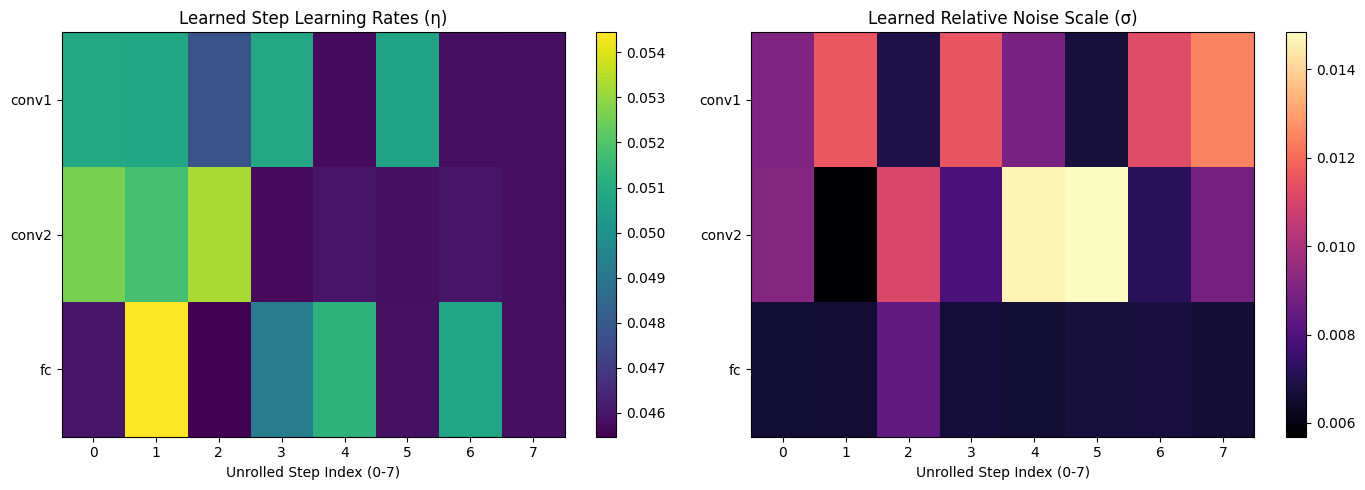

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Primary Model Definition
# ==========================================
class PrimaryCNN(nn.Module):
    def __init__(self):
        super(PrimaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 10)
        self._init_bad_weights()

    def _init_bad_weights(self):
        # Intentionally poor, high-variance initialization to test noise recovery
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.normal_(m.weight, mean=0.0, std=0.3)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x, params=None):
        if params is None:
            w_c1, b_c1 = self.conv1.weight, self.conv1.bias
            w_c2, b_c2 = self.conv2.weight, self.conv2.bias
            w_fc, b_fc = self.fc.weight, self.fc.bias
        else:
            w_c1, b_c1 = params['conv1.weight'], params['conv1.bias']
            w_c2, b_c2 = params['conv2.weight'], params['conv2.bias']
            w_fc, b_fc = params['fc.weight'], params['fc.bias']

        x = F.relu(F.max_pool2d(F.conv2d(x, w_c1, b_c1, padding=1), 2))
        x = F.relu(F.max_pool2d(F.conv2d(x, w_c2, b_c2, padding=1), 2))
        x = x.view(x.size(0), -1)
        x = F.linear(x, w_fc, b_fc)
        return x

# ==========================================
# 2. Meta-Scheduler Module
# ==========================================
class MetaScheduleWithNoise(nn.Module):
    def __init__(self, num_steps=8, num_layer_groups=3):
        super(MetaScheduleWithNoise, self).__init__()
        # Initialize LRs around 0.05
        self.log_lrs = nn.Parameter(torch.full((num_steps, num_layer_groups), -3.0))
        # Initialize Noise Std around 0.01 (-4.6 in log space)
        self.log_noise = nn.Parameter(torch.full((num_steps, num_layer_groups), -4.6))

    def get_schedule(self, step_idx):
        lr = torch.exp(self.log_lrs[step_idx])
        noise_std = torch.exp(self.log_noise[step_idx])
        return lr, noise_std

# ==========================================
# 3. Setup & Training
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

UNROLL_STEPS = 8
primary_model = PrimaryCNN().to(device)
schedule = MetaScheduleWithNoise(num_steps=UNROLL_STEPS, num_layer_groups=3).to(device)

# Separate learning rates: High LR for log_noise to force dynamic movement
meta_optimizer = torch.optim.Adam([
    {'params': primary_model.parameters(), 'lr': 1e-3},
    {'params': schedule.log_lrs, 'lr': 1e-2},
    {'params': schedule.log_noise, 'lr': 5e-2}  # Boosted meta-learning rate for noise
])

NUM_META_EPOCHS = 60
print("Running Meta-Optimization with Poor Initialization (std=0.3)...\n")

for meta_epoch in range(1, NUM_META_EPOCHS + 1):
    data_iter = iter(train_loader)
    fast_params = {name: param.clone() for name, param in primary_model.named_parameters()}

    for step in range(UNROLL_STEPS):
        data, target = next(data_iter)
        data, target = data.to(device), target.to(device)

        out = primary_model(data, params=fast_params)
        loss = F.cross_entropy(out, target)

        grads = torch.autograd.grad(loss, fast_params.values(), create_graph=True)
        step_lrs, step_noise = schedule.get_schedule(step)

        new_fast_params = {}
        for (name, param), grad in zip(fast_params.items(), grads):
            if 'conv1' in name:
                idx = 0
            elif 'conv2' in name:
                idx = 1
            else:
                idx = 2

            lr, std = step_lrs[idx], step_noise[idx]
            # Relative parameter-scaled noise injection
            param_norm = torch.norm(param).detach() + 1e-8
            noise = torch.randn_like(param) * (std * param_norm)

            new_fast_params[name] = param - lr * grad + noise

        fast_params = new_fast_params

    # Outer loop update
    meta_data, meta_target = next(data_iter)
    meta_data, meta_target = meta_data.to(device), meta_target.to(device)

    meta_out = primary_model(meta_data, params=fast_params)
    meta_loss = F.cross_entropy(meta_out, meta_target)

    meta_optimizer.zero_grad()
    meta_loss.backward()
    meta_optimizer.step()

# ==========================================
# 4. Plotting Learned Heatmaps
# ==========================================
learned_lrs = np.zeros((UNROLL_STEPS, 3))
learned_noise = np.zeros((UNROLL_STEPS, 3))

for s in range(UNROLL_STEPS):
    lrs, noise = schedule.get_schedule(s)
    learned_lrs[s] = lrs.detach().cpu().numpy()
    learned_noise[s] = noise.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layers = ['conv1', 'conv2', 'fc']

# Plot Learning Rate Heatmap
im1 = axes[0].imshow(learned_lrs.T, cmap='viridis', aspect='auto')
axes[0].set_title("Learned Step Learning Rates (η)")
axes[0].set_xlabel("Unrolled Step Index (0-7)")
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(layers)
fig.colorbar(im1, ax=axes[0])

# Plot Noise Std Heatmap
im2 = axes[1].imshow(learned_noise.T, cmap='magma', aspect='auto')
axes[1].set_title("Learned Relative Noise Scale (σ)")
axes[1].set_xlabel("Unrolled Step Index (0-7)")
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(layers)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

Training Meta-Scheduler on Random Initializations per Meta-Epoch...

Meta-Epoch [20/60] | Trajectory Validation Loss: 5.0030
Meta-Epoch [40/60] | Trajectory Validation Loss: 4.1509
Meta-Epoch [60/60] | Trajectory Validation Loss: 2.6433


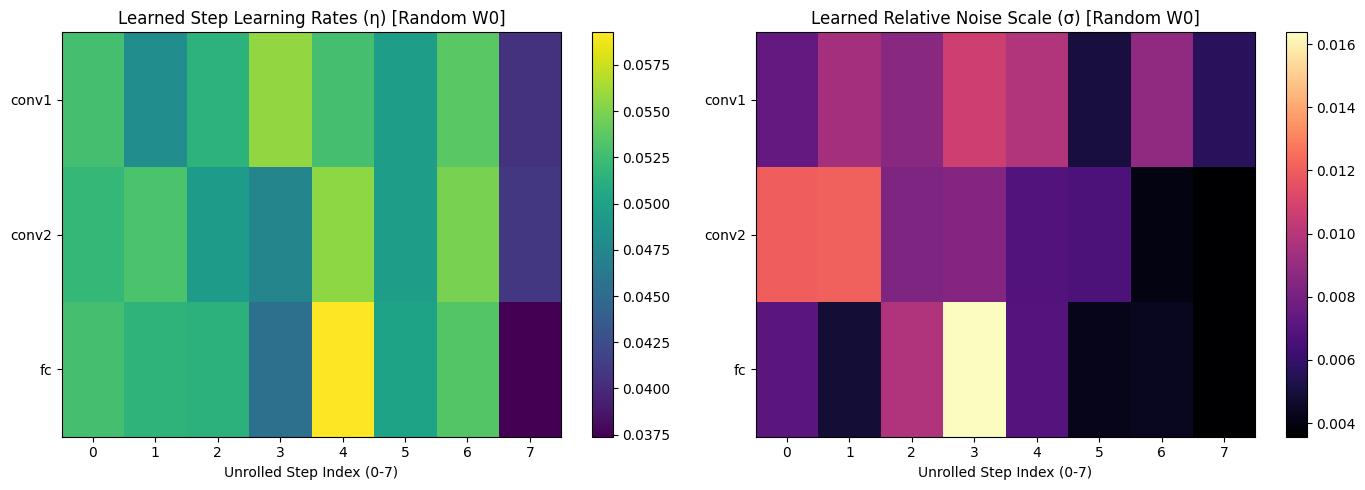

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Primary Model Definition
# ==========================================
class PrimaryCNN(nn.Module):
    def __init__(self):
        super(PrimaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def reinitialize_weights(self):
        """Randomize W0 weights from standard initialization every meta-epoch."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=np.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
                    nn.init.uniform_(m.bias, -bound, bound)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=np.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
                    nn.init.uniform_(m.bias, -bound, bound)

    def forward(self, x, params=None):
        if params is None:
            w_c1, b_c1 = self.conv1.weight, self.conv1.bias
            w_c2, b_c2 = self.conv2.weight, self.conv2.bias
            w_fc, b_fc = self.fc.weight, self.fc.bias
        else:
            w_c1, b_c1 = params['conv1.weight'], params['conv1.bias']
            w_c2, b_c2 = params['conv2.weight'], params['conv2.bias']
            w_fc, b_fc = params['fc.weight'], params['fc.bias']

        x = F.relu(F.max_pool2d(F.conv2d(x, w_c1, b_c1, padding=1), 2))
        x = F.relu(F.max_pool2d(F.conv2d(x, w_c2, b_c2, padding=1), 2))
        x = x.view(x.size(0), -1)
        x = F.linear(x, w_fc, b_fc)
        return x

# ==========================================
# 2. Meta-Scheduler Module
# ==========================================
class MetaScheduleWithNoise(nn.Module):
    def __init__(self, num_steps=8, num_layer_groups=3):
        super(MetaScheduleWithNoise, self).__init__()
        self.log_lrs = nn.Parameter(torch.full((num_steps, num_layer_groups), -3.0))
        self.log_noise = nn.Parameter(torch.full((num_steps, num_layer_groups), -4.6))

    def get_schedule(self, step_idx):
        lr = torch.exp(self.log_lrs[step_idx])
        noise_std = torch.exp(self.log_noise[step_idx])
        return lr, noise_std

# ==========================================
# 3. Setup Data & Meta-Optimizer
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

UNROLL_STEPS = 8
primary_model = PrimaryCNN().to(device)
schedule = MetaScheduleWithNoise(num_steps=UNROLL_STEPS, num_layer_groups=3).to(device)

# Meta-optimizer ONLY updates the schedule parameters (W0 is excluded)
meta_optimizer = torch.optim.Adam([
    {'params': schedule.log_lrs, 'lr': 1e-2},
    {'params': schedule.log_noise, 'lr': 5e-2}
])

NUM_META_EPOCHS = 60
print("Training Meta-Scheduler on Random Initializations per Meta-Epoch...\n")

for meta_epoch in range(1, NUM_META_EPOCHS + 1):
    # Re-sample random initial weights W0 at the start of every meta-epoch
    # primary_model.reinitialize_weights()

    data_iter = iter(train_loader)
    fast_params = {name: param.clone() for name, param in primary_model.named_parameters()}

    # --- INNER LOOP (Unrolled Step Sequence) ---
    for step in range(UNROLL_STEPS):
        data, target = next(data_iter)
        data, target = data.to(device), target.to(device)

        out = primary_model(data, params=fast_params)
        loss = F.cross_entropy(out, target)

        grads = torch.autograd.grad(loss, fast_params.values(), create_graph=True)
        step_lrs, step_noise = schedule.get_schedule(step)

        new_fast_params = {}
        for (name, param), grad in zip(fast_params.items(), grads):
            if 'conv1' in name:
                idx = 0
            elif 'conv2' in name:
                idx = 1
            else:
                idx = 2

            lr, std = step_lrs[idx], step_noise[idx]
            param_norm = torch.norm(param).detach() + 1e-8
            noise = torch.randn_like(param) * (std * param_norm)

            new_fast_params[name] = param - lr * grad + noise

        fast_params = new_fast_params

    # --- OUTER LOOP (Update Schedule) ---
    meta_data, meta_target = next(data_iter)
    meta_data, meta_target = meta_data.to(device), meta_target.to(device)

    meta_out = primary_model(meta_data, params=fast_params)
    meta_loss = F.cross_entropy(meta_out, meta_target)

    meta_optimizer.zero_grad()
    meta_loss.backward()
    meta_optimizer.step()

    if meta_epoch % 20 == 0:
        print(f"Meta-Epoch [{meta_epoch}/{NUM_META_EPOCHS}] | Trajectory Validation Loss: {meta_loss.item():.4f}")

# ==========================================
# 4. Heatmap Plotting
# ==========================================
learned_lrs = np.zeros((UNROLL_STEPS, 3))
learned_noise = np.zeros((UNROLL_STEPS, 3))

for s in range(UNROLL_STEPS):
    lrs, noise = schedule.get_schedule(s)
    learned_lrs[s] = lrs.detach().cpu().numpy()
    learned_noise[s] = noise.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layers = ['conv1', 'conv2', 'fc']

im1 = axes[0].imshow(learned_lrs.T, cmap='viridis', aspect='auto')
axes[0].set_title("Learned Step Learning Rates (η) [Random W0]")
axes[0].set_xlabel("Unrolled Step Index (0-7)")
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(layers)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(learned_noise.T, cmap='magma', aspect='auto')
axes[1].set_title("Learned Relative Noise Scale (σ) [Random W0]")
axes[1].set_xlabel("Unrolled Step Index (0-7)")
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(layers)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

test if ending learning rate boost persists to longer training

Starting Joint Meta-Optimization over 24 Unrolled Steps...

Meta-Epoch [01/80] | Val Loss: 1.4816 | Step 0 Loss: 2.2847 -> Step 23 Loss: 1.8712 | Test Acc: 66.44%
Meta-Epoch [10/80] | Val Loss: 0.9939 | Step 0 Loss: 2.3162 -> Step 23 Loss: 1.1183 | Test Acc: 65.85%
Meta-Epoch [20/80] | Val Loss: 1.0295 | Step 0 Loss: 2.3502 -> Step 23 Loss: 0.9450 | Test Acc: 74.27%
Meta-Epoch [30/80] | Val Loss: 0.7005 | Step 0 Loss: 2.3534 -> Step 23 Loss: 0.8098 | Test Acc: 70.42%
Meta-Epoch [40/80] | Val Loss: 0.7143 | Step 0 Loss: 2.3062 -> Step 23 Loss: 0.6784 | Test Acc: 82.51%
Meta-Epoch [50/80] | Val Loss: 0.8145 | Step 0 Loss: 2.3379 -> Step 23 Loss: 0.8820 | Test Acc: 73.02%
Meta-Epoch [60/80] | Val Loss: 0.9190 | Step 0 Loss: 2.3342 -> Step 23 Loss: 1.1850 | Test Acc: 70.71%
Meta-Epoch [70/80] | Val Loss: 0.8037 | Step 0 Loss: 2.3099 -> Step 23 Loss: 0.9010 | Test Acc: 77.66%
Meta-Epoch [80/80] | Val Loss: 0.9703 | Step 0 Loss: 2.3084 -> Step 23 Loss: 1.0256 | Test Acc: 66.34%


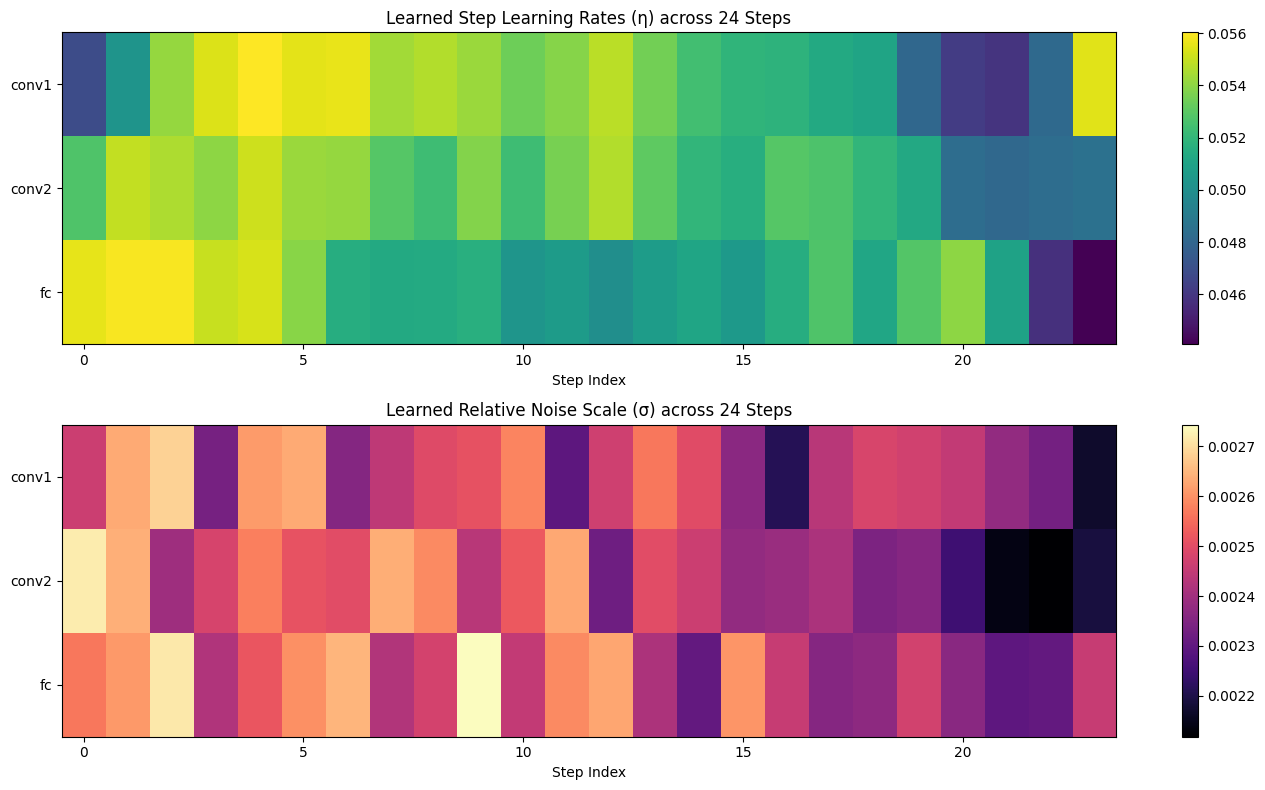

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Primary Model Definition
# ==========================================
class PrimaryCNN(nn.Module):
    def __init__(self):
        super(PrimaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def reinitialize_weights(self):
        """Randomize W0 weights from standard initialization every meta-epoch."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, a=np.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
                    nn.init.uniform_(m.bias, -bound, bound)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=np.sqrt(5))
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
                    nn.init.uniform_(m.bias, -bound, bound)

    def forward(self, x, params=None):
        if params is None:
            w_c1, b_c1 = self.conv1.weight, self.conv1.bias
            w_c2, b_c2 = self.conv2.weight, self.conv2.bias
            w_fc, b_fc = self.fc.weight, self.fc.bias
        else:
            w_c1, b_c1 = params['conv1.weight'], params['conv1.bias']
            w_c2, b_c2 = params['conv2.weight'], params['conv2.bias']
            w_fc, b_fc = params['fc.weight'], params['fc.bias']

        x = F.relu(F.max_pool2d(F.conv2d(x, w_c1, b_c1, padding=1), 2))
        x = F.relu(F.max_pool2d(F.conv2d(x, w_c2, b_c2, padding=1), 2))
        x = x.view(x.size(0), -1)
        x = F.linear(x, w_fc, b_fc)
        return x

# ==========================================
# 2. Meta-Scheduler Module
# ==========================================
class MetaScheduleWithNoise(nn.Module):
    def __init__(self, num_steps=24, num_layer_groups=3):
        super(MetaScheduleWithNoise, self).__init__()
        self.log_lrs = nn.Parameter(torch.full((num_steps, num_layer_groups), -3.0))
        self.log_noise = nn.Parameter(torch.full((num_steps, num_layer_groups), -6.0))

    def get_schedule(self, step_idx):
        # Clamp log bounds to keep LRs and Noise in stable ranges
        log_lrs_clamped = torch.clamp(self.log_lrs[step_idx], min=-5.0, max=-1.0)
        log_noise_clamped = torch.clamp(self.log_noise[step_idx], min=-7.0, max=-2.0)
        lr = torch.exp(self.log_lrs[step_idx])
        noise_std = torch.exp(self.log_noise[step_idx])
        return lr, noise_std

# ==========================================
# 3. Setup Data & Optimizers
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

UNROLL_STEPS = 24  # Increased step horizon
primary_model = PrimaryCNN().to(device)
schedule = MetaScheduleWithNoise(num_steps=UNROLL_STEPS, num_layer_groups=3).to(device)

# Jointly train W0 and the schedule to reach ~98% accuracy
meta_optimizer = torch.optim.Adam([
    {'params': primary_model.parameters(), 'lr': 1e-3},
    {'params': schedule.log_lrs, 'lr': 2e-3},
    {'params': schedule.log_noise, 'lr': 5e-3}
])

def evaluate_accuracy(model, fast_params):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            out = model(data, params=fast_params)
            pred = out.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    model.train()
    return 100.0 * correct / total

# ==========================================
# 4. Meta-Training Loop with Detailed Logs
# ==========================================
NUM_META_EPOCHS = 80
print(f"Starting Joint Meta-Optimization over {UNROLL_STEPS} Unrolled Steps...\n")

for meta_epoch in range(1, NUM_META_EPOCHS + 1):
    # primary_model.reinitialize_weights()
    data_iter = iter(train_loader)
    fast_params = {name: param.clone() for name, param in primary_model.named_parameters()}

    step_losses = []

    for step in range(UNROLL_STEPS):
        data, target = next(data_iter)
        data, target = data.to(device), target.to(device)

        out = primary_model(data, params=fast_params)
        loss = F.cross_entropy(out, target)
        step_losses.append(loss.item())

        grads = torch.autograd.grad(loss, fast_params.values(), create_graph=True)

        # Use 8 schedule slots across 24 data batches (3 batches per schedule step)
        schedule_step = step // 3
        step_lrs, step_noise = schedule.get_schedule(step)
        # Add internal gradient clipping to stabilize the graph trajectory
        grads = [torch.clamp(g, -1.0, 1.0) for g in grads]

        new_fast_params = {}
        for (name, param), grad in zip(fast_params.items(), grads):
            idx = 0 if 'conv1' in name else (1 if 'conv2' in name else 2)
            lr, std = step_lrs[idx], step_noise[idx]

            param_norm = torch.norm(param).detach() + 1e-8
            noise = torch.randn_like(param) * std

            new_fast_params[name] = param - lr * grad + noise

        fast_params = new_fast_params

    # Meta-Update on Validation Data
    meta_data, meta_target = next(data_iter)
    meta_data, meta_target = meta_data.to(device), meta_target.to(device)
    meta_out = primary_model(meta_data, params=fast_params)
    meta_loss = F.cross_entropy(meta_out, meta_target)

    meta_optimizer.zero_grad()
    meta_loss.backward()
    # Add gradient clipping before the step to avoid nan explosion
    torch.nn.utils.clip_grad_norm_(primary_model.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(schedule.parameters(), 1.0)
    meta_optimizer.step()

    # Logging Metrics
    if meta_epoch % 10 == 0 or meta_epoch == 1:
        test_acc = evaluate_accuracy(primary_model, fast_params)
        init_loss = step_losses[0]
        final_loss = step_losses[-1]
        print(f"Meta-Epoch [{meta_epoch:02d}/{NUM_META_EPOCHS}] | "
              f"Val Loss: {meta_loss.item():.4f} | "
              f"Step 0 Loss: {init_loss:.4f} -> Step {UNROLL_STEPS-1} Loss: {final_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}%")

# ==========================================
# 5. Visualization
# ==========================================
learned_lrs = np.zeros((UNROLL_STEPS, 3))
learned_noise = np.zeros((UNROLL_STEPS, 3))

for s in range(UNROLL_STEPS):
    lrs, noise = schedule.get_schedule(s)
    learned_lrs[s] = lrs.detach().cpu().numpy()
    learned_noise[s] = noise.detach().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
layers = ['conv1', 'conv2', 'fc']

im1 = axes[0].imshow(learned_lrs.T, cmap='viridis', aspect='auto')
axes[0].set_title(f"Learned Step Learning Rates (η) across {UNROLL_STEPS} Steps")
axes[0].set_xlabel("Step Index")
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(layers)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(learned_noise.T, cmap='magma', aspect='auto')
axes[1].set_title(f"Learned Relative Noise Scale (σ) across {UNROLL_STEPS} Steps")
axes[1].set_xlabel("Step Index")
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(layers)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

### talking to gem about Eigenvalues ($\lambda_{\max}$) and the Maximum Learning Rate Limit

In [15]:
import torch

# Define a 2D quadratic loss landscape with sharp curvature along x (Hessian = [[200, 0], [0, 2]])
# Loss L(x, y) = 100*x^2 + 1*y^2
# Curvature along x is steep (200), along y is gentle (2).
# Maximum eigenvalue lambda_max = 200. Max stable LR = 2 / 200 = 0.01.

def compute_loss(w):
    return 100.0 * (w[0]**2) + 1.0 * (w[1]**2)

# Test 1: Stable Learning Rate (LR = 0.009 < 2 / lambda_max)
w_stable = torch.tensor([5.0, 5.0], requires_grad=True)
lr_stable = 0.009

print("--- Testing Stable Step (LR = 0.009) ---")
for step in range(5):
    loss = compute_loss(w_stable)
    loss.backward()
    with torch.no_grad():
        w_stable -= lr_stable * w_stable.grad
        w_stable.grad.zero_()
    print(f"Step {step+1} | Loss: {loss.item():.4f} | w: [{w_stable[0].item():.2f}, {w_stable[1].item():.2f}]")

print("\n--- Testing Unstable Step (LR = 0.011 > 2 / lambda_max) ---")
# Test 2: Unstable Learning Rate (LR = 0.011 > 2 / lambda_max)
w_unstable = torch.tensor([5.0, 5.0], requires_grad=True)
lr_unstable = 0.011

for step in range(5):
    loss = compute_loss(w_unstable)
    loss.backward()
    with torch.no_grad():
        w_unstable -= lr_unstable * w_unstable.grad
        w_unstable.grad.zero_()
    print(f"Step {step+1} | Loss: {loss.item():.4f} | w: [{w_unstable[0].item():.2f}, {w_unstable[1].item():.2f}]")

--- Testing Stable Step (LR = 0.009) ---
Step 1 | Loss: 2525.0000 | w: [-4.00, 4.91]
Step 2 | Loss: 1624.1082 | w: [3.20, 4.82]
Step 3 | Loss: 1047.2479 | w: [-2.56, 4.73]
Step 4 | Loss: 677.7784 | w: [2.05, 4.65]
Step 5 | Loss: 441.0490 | w: [-1.64, 4.57]

--- Testing Unstable Step (LR = 0.011 > 2 / lambda_max) ---
Step 1 | Loss: 2525.0000 | w: [-6.00, 4.89]
Step 2 | Loss: 3623.9121 | w: [7.20, 4.78]
Step 3 | Loss: 5206.8711 | w: [-8.64, 4.68]
Step 4 | Loss: 7486.8369 | w: [10.37, 4.57]
Step 5 | Loss: 10770.4688 | w: [-12.44, 4.47]


In [16]:
import torch

# Parameter vector w = [x, y]
w_A = torch.tensor([1.0, 1.0], requires_grad=True)
w_B = torch.tensor([1.0, 1.0], requires_grad=True)

# Surface A: Uncoupled (Off-diagonal = 0)
# L_A = 10*x^2 + 10*y^2
loss_A = 10.0 * w_A[0]**2 + 10.0 * w_A[1]**2
loss_A.backward()

# Surface B: Coupled/Rotated Canyon (Off-diagonal = 120)
# L_B = 10*x^2 + 10*y^2 + 120*x*y
loss_B = 10.0 * w_B[0]**2 + 10.0 * w_B[1]**2 + 120.0 * w_B[0] * w_B[1]
loss_B.backward()

print("--- Uncoupled Surface A Gradients ---")
print(f"dL/dx: {w_A.grad[0]:.1f}, dL/dy: {w_A.grad[1]:.1f}")

print("\n--- Coupled Surface B Gradients ---")
print(f"dL/dx: {w_B.grad[0]:.1f}, dL/dy: {w_B.grad[1]:.1f}")
# Notice how adding the x*y interaction term dramatically exploded
# the gradients in BOTH directions simultaneously!

--- Uncoupled Surface A Gradients ---
dL/dx: 20.0, dL/dy: 20.0

--- Coupled Surface B Gradients ---
dL/dx: 140.0, dL/dy: 140.0


In [ ]:
import torch

def compute_max_hessian_eigenvalue(model, loss, num_iterations=15):
    """
    Computes lambda_max (spectral radius of the Hessian)
    using Power Iteration with Hessian-Vector Products.
    """
    params = [p for p in model.parameters() if p.requires_grad]

    # 1. First-order gradient: g = dL/dw
    grads = torch.autograd.grad(loss, params, create_graph=True)

    # 2. Initialize a random vector v with unit length (||v|| = 1)
    v = [torch.randn_like(p) for p in params]
    v_norm = torch.sqrt(sum(torch.sum(vi ** 2) for vi in v))
    v = [vi / (v_norm + 1e-8) for vi in v]

    lambda_max = 0.0

    # 3. Power Iteration Loop
    for _ in range(num_iterations):
        # Compute dot product g * v
        grad_v_dot = sum(torch.sum(gi * vi) for gi, vi in zip(grads, v))

        # Hessian-Vector Product: Hv = d(g * v)/dw
        Hv = torch.autograd.grad(grad_v_dot, params, retain_graph=True)

        # Estimate eigenvalue via Rayleigh quotient: lambda = v^T * H * v
        lambda_max = sum(torch.sum(vi * Hvi) for vi, Hvi in zip(v, Hv)).item()

        # Normalize Hv for the next iteration step: v_{k+1} = Hv / ||Hv||
        Hv_norm = torch.sqrt(sum(torch.sum(Hvi ** 2) for Hvi in Hv))
        v = [Hvi / (Hv_norm + 1e-8) for Hvi in Hv]

    return lambda_max

# --- Example Usage ---
# loss = F.cross_entropy(model(x), y)
# max_lambda = compute_max_hessian_eigenvalue(model, loss)
# max_stable_lr = 2.0 / max_lambda
# print(f"Lambda Max: {max_lambda:.4f} | Theoretical Max Stable LR: {max_stable_lr:.4f}")